# 06e — Bidirectional leave-one-family-out transfer

In [6]:
%matplotlib inline
import os, sys
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR','/tmp/matplotlib')
PROJECT_ROOT=Path.cwd().resolve()
while PROJECT_ROOT!=PROJECT_ROOT.parent and not (PROJECT_ROOT/'src'/'lss').exists(): PROJECT_ROOT=PROJECT_ROOT.parent
if str(PROJECT_ROOT/'src') not in sys.path: sys.path.insert(0,str(PROJECT_ROOT/'src'))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lss.data import load_dataset, tag_simulation_source
from lss.latent.experiment import evaluate_autoencoder_reconstruction_horizons, evaluate_rollout_horizons, run_latent_experiment, seed_everything
from lss.latent.simulation import set_reference_context_mode
from lss.plotting import PAPER_COLORS, apply_editorial_style, dataset_color, style_axes
apply_editorial_style(); plt.rcParams.update({'figure.dpi':180,'savefig.dpi':400})
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [7]:
SEED=76324
FORCE_TRAIN=False
TRAIN_NETWORKS,VAL_NETWORKS,TEST_NETWORKS=10,20,70
TRAIN_STEPS_PER_SIM=100
MAX_EPOCHS,PATIENCE=50,10
LEARNING_RATE,WEIGHT_DECAY=1e-4,1e-5
ROLLOUT_STEPS=[0,25,50,75,100,125,150,175,199]
OUTPUT=PROJECT_ROOT/'notebooks/results/06e_zero_shot_mixed_temperature_transfer_boxnorm'; OUTPUT.mkdir(parents=True,exist_ok=True)
DEPABLO=PROJECT_ROOT/'data/depablo-near-zero-temp.pt'
REID=PROJECT_ROOT/'data/reid_200_frames.pt'
for path in (DEPABLO,REID): assert path.exists(),path
print({'device':str(DEVICE),'normalization':'initial box -> [-1,1]^2','latent_dim':2,'train networks per bundle':TRAIN_NETWORKS})

{'device': 'cuda', 'normalization': 'initial box -> [-1,1]^2', 'latent_dim': 2, 'train networks per bundle': 10}


## Source-only bundles

In [8]:
FAMILIES={
 'depablo_low_temp':{'label':'de Pablo','path':DEPABLO,'color_key':'depablo_low_temp','stiffness_exponent':1},
 'reid':{'label':'Reid','path':REID,'color_key':'reid','stiffness_exponent':1},
}
DIRECTIONS=[('depablo_low_temp','reid'),('reid','depablo_low_temp')]
AE_CONFIG={
 'latent_dim':2,'latent_tokens':32,'hidden_size':96,'model':'attention','edge_feature_dim':4,'target_mode':'normalized_delta','node_feature_mode':'normalized_delta',
 'train_frame_skip':1,'max_train_frames_per_sim':TRAIN_STEPS_PER_SIM+1,'val_frame_skip':1,'max_val_frames_per_sim':TRAIN_STEPS_PER_SIM+1,
 'max_epochs':MAX_EPOCHS,'patience':PATIENCE,'lr':LEARNING_RATE,'weight_decay':WEIGHT_DECAY,'balance_sources':True,'mix_sources':True,'train_rows_per_source':TRAIN_NETWORKS*(TRAIN_STEPS_PER_SIM+1)}
PROPAGATOR_CONFIG={
 'max_train_transitions_per_sim':TRAIN_STEPS_PER_SIM,'max_epochs':MAX_EPOCHS,'patience':PATIENCE,'lr':LEARNING_RATE,'weight_decay':WEIGHT_DECAY,
 'hidden_size':128,'loss':'delta','step_stride':1,'mix_sources':True,'use_static_context':True,'context_dim':16,'context_pool':'moments',
 'rollout_eval_every_epoch':True,'rollout_eval_horizons':[100],'rollout_eval_max_sims':None,
 'objective':'fixed_history_one_step','model':'fixed_velocity_residual_mlp','fixed_observed_frames':(1,5),'multistep_horizons':[1]}
BASE={
 'ae_config':AE_CONFIG,'propagator_config':PROPAGATOR_CONFIG,
 'split_seed':SEED,'split_stratify_temperature':False,'min_train_p_ratio':None,'device':str(DEVICE),'pos_dim':2,'batch_graphs':32,'frame_skip':1,'train_frame_start_order':0,
 'coordinate_normalization':'position_normalization','edge_mode':'compact_stored','edge_feature_schema':'compact_unique_edge_changes_v1','reference_context_mode':'normalized',
 'rollout_steps_grid':ROLLOUT_STEPS,'rollout_eval_splits':[],'early_stop_min_delta':1e-5,'should_rollout':True,'should_train_propagator':True,
 'cache_require_matching_config':True,'force_train':FORCE_TRAIN,'model_seed':SEED,'repeat_idx':1}
bundles={}
for train_key,test_key in DIRECTIONS:
 family=FAMILIES[train_key]; direction=f'{train_key}_to_{test_key}'
 source={
  'dataset_name':direction,'source_name':train_key,'label':f"{family['label']} source-only bundle",'path':str(family['path']),
  'dataset_mixture':[{'name':train_key,'label':family['label'],'path':str(family['path']),'train_count':TRAIN_NETWORKS,'val_count':VAL_NETWORKS,'edge_stiffness_length_exponent':family['stiffness_exponent']}],
  'edge_mode':'compact_stored','edge_feature_schema':'compact_unique_edge_changes_v1'}
 experiment_config={**BASE,'cache_path':str(OUTPUT/f'model_{direction}_generic_ae_dimensionless_fullrange_v5.pt'),
      'propagator_config':{**PROPAGATOR_CONFIG,'train_trajectories_per_source':{train_key:TRAIN_NETWORKS},'val_trajectories_per_source':{train_key:VAL_NETWORKS}}}
 seed_everything(SEED); bundles[(train_key,test_key)]=run_latent_experiment(source,experiment_config,device=DEVICE)
display(pd.DataFrame([{'train family':FAMILIES[a]['label'],'unseen test family':FAMILIES[b]['label'],'AE training families':FAMILIES[a]['label'],'propagator training families':FAMILIES[a]['label']} for a,b in DIRECTIONS]))


=== de Pablo source-only bundle ===
          source                                                                path  total  train  reserved_train_pool  val  test
depablo_low_temp /home/alexz/Documents/course_project/data/depablo-near-zero-temp.pt    200     10                   10   20   170
source-balanced AE rows: {'depablo_low_temp': 2000}
source-mixed AE coverage: {'depablo_low_temp': {'trajectories': 10, 'frames': 2000}}
autoencoder
ae 0001 train=1.08235 val=0.815263 stale=0
ae 0002 train=0.98593 val=0.628231 stale=0
ae 0003 train=0.675784 val=0.432286 stale=0
ae 0010 train=0.365387 val=0.546604 stale=7
ae early stop at epoch 0015; best_epoch=0003 best_val=0.432286
propagator training coverage: {'depablo_low_temp': {'trajectories': 10, 'transitions': 1000}}
latent propagator: objective=fixed_history_one_step step_stride=1 horizons=[1] train_rows=1000 val_rows=2000
precomputing frozen AE latents for one-step history training
latent history training: steps=1, max_epochs=50
pro

,train family,unseen test family,AE training families,propagator training families
0,de Pablo,Reid,de Pablo,de Pablo
1,Reid,de Pablo,Reid,Reid


## Unseen-family rollout

In [9]:
parts=[]
for direction_index,(train_key,test_key) in enumerate(DIRECTIONS):
 result=bundles[(train_key,test_key)]; target=FAMILIES[test_key]
 target_all=load_dataset(target['path'],coordinate_normalization='position_normalization',edge_stiffness_length_exponent=target['stiffness_exponent'])
 order=torch.randperm(len(target_all),generator=torch.Generator().manual_seed(SEED+404+direction_index)).tolist()
 target_test=[tag_simulation_source(target_all[i],test_key) for i in order[:min(TEST_NETWORKS,len(target_all))]]; set_reference_context_mode(target_test,result['params']['reference_context_mode'])
 eval_cfg={**result['params'],'dataset_name':test_key}
 _,rollout=evaluate_rollout_horizons(result['ae'],result['dyn'],target_test,result['latent_stats'],experiment_config=eval_cfg,normalizers=result['normalizers'],dataset=target['label'],split_name='unseen-family',rollout_steps=ROLLOUT_STEPS,device=DEVICE)
 rollout['model']='latent rollout'; parts.append(rollout)
 _,direct=evaluate_autoencoder_reconstruction_horizons(result['ae'],target_test,experiment_config=eval_cfg,normalizers=result['normalizers'],dataset=target['label'],split_name='unseen-family',rollout_steps=ROLLOUT_STEPS,device=DEVICE)
 direct['model']='direct Autoencoder'; parts.append(direct)
 for frame in (rollout,direct):
  frame['train_family']=FAMILIES[train_key]['label']; frame['test_family']=target['label']; frame['direction']=f"{FAMILIES[train_key]['label']} → {target['label']}"
comparison=pd.concat(parts,ignore_index=True)
comparison.to_csv(OUTPUT/'bidirectional_source_only_transfer.csv',index=False)
display(comparison[['direction','model','rollout_steps','used','p_ratio_r2','p_ratio_pearson','final_pos_mse']].round(5))

,direction,model,rollout_steps,used,p_ratio_r2,p_ratio_pearson,final_pos_mse
0,de Pablo → Reid,latent rollout,25,70,-0.41247,-0.04153,0.00078
1,de Pablo → Reid,latent rollout,50,70,-0.31516,-0.04614,0.00078
2,de Pablo → Reid,latent rollout,75,70,-0.26857,-0.05067,0.00078
3,de Pablo → Reid,latent rollout,100,70,-0.23540,-0.05452,0.00078
4,de Pablo → Reid,latent rollout,125,70,-0.20841,-0.05779,0.00079
5,de Pablo → Reid,latent rollout,150,70,-0.18515,-0.06052,0.00080
6,de Pablo → Reid,latent rollout,175,70,-0.16471,-0.06282,0.00081
7,de Pablo → Reid,latent rollout,199,70,-0.14713,-0.06460,0.00082
8,de Pablo → Reid,direct Autoencoder,25,70,-0.41261,-0.04260,0.00078
9,de Pablo → Reid,direct Autoencoder,50,70,-0.31554,-0.04957,0.00079


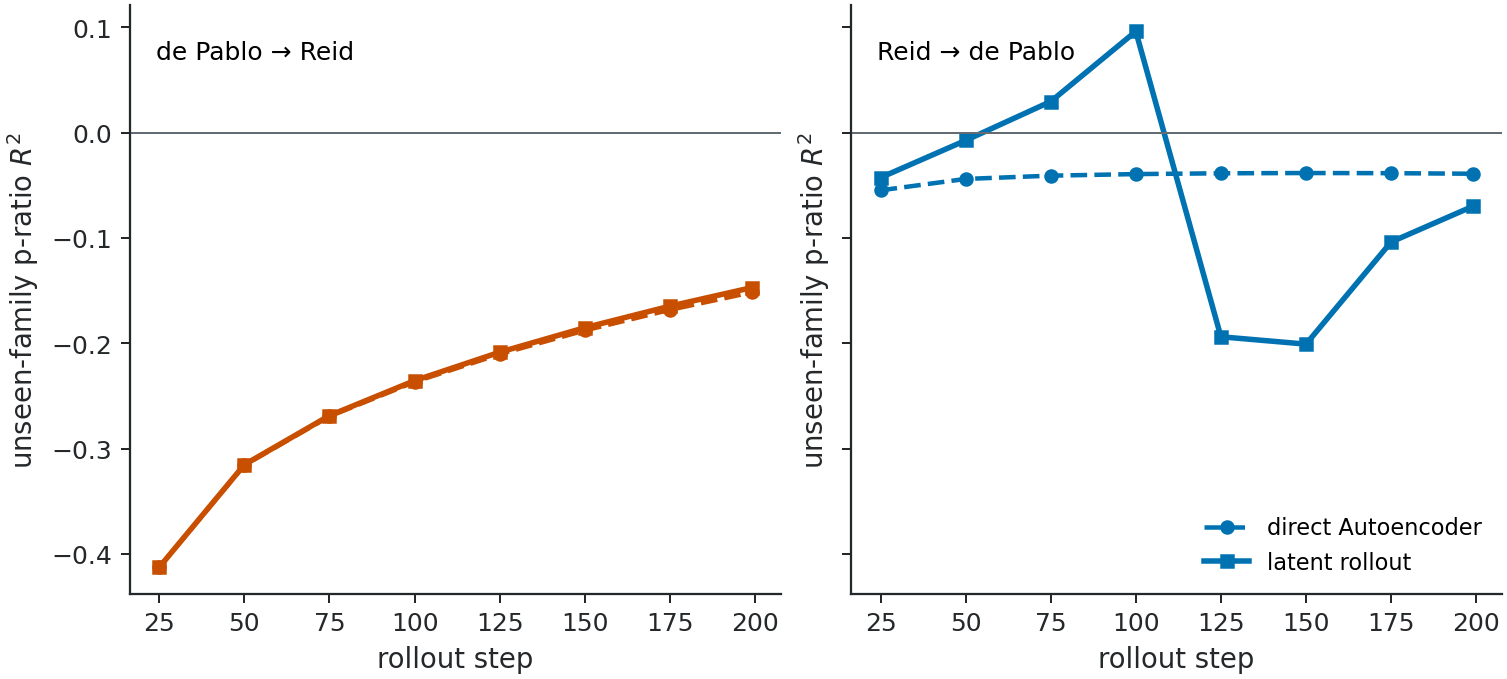

In [10]:
fig,axes=plt.subplots(1,2,figsize=(8.4,3.8),sharex=True,sharey=True,constrained_layout=True)
styles={'direct Autoencoder':('--','o',1.8),'latent rollout':('-','s',2.2)}
for ax,(train_key,test_key) in zip(axes,DIRECTIONS):
 direction=f"{FAMILIES[train_key]['label']} → {FAMILIES[test_key]['label']}"; color=dataset_color(FAMILIES[test_key]['color_key'])
 for label,(linestyle,marker,width) in styles.items():
  rows=comparison[comparison.direction.eq(direction)&comparison.model.eq(label)].sort_values('rollout_steps')
  ax.plot(rows.rollout_steps,rows.p_ratio_r2,color=color,linestyle=linestyle,marker=marker,linewidth=width,markersize=4.8,label=label)
 ax.axhline(0,color=PAPER_COLORS['slate'],linewidth=.8); style_axes(ax,xlabel='rollout step',ylabel=r'unseen-family p-ratio $R^2$',legend=False); ax.text(.04,.94,direction,transform=ax.transAxes,ha='left',va='top')
axes[1].legend(frameon=False,loc='lower right'); plt.show()